In [1]:
import scipy

from src.utils import ingaas_processing
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import cv2

In [2]:
#scan_path = "F://Work//LIPI//scans//scan_20260226_152601.raw"
#scan_path = "F://Work//LIPI//scans//outside//scan_20260319_142551.raw"
#scan_path = "F://Work//LIPI//scans//outside//scan_20260319_144342.raw"
#scan_path = "C://Users//jeppe//Documents//LIPI//scans//test2//scan_20260226_152601.raw"
#scan_path = "C://Users//jeppe//Documents//LIPI//scans//outside//scan_20260319_142551.raw"
#scan_path = "C://Users//jeppe//Documents//LIPI//scans//outside2//scan_20260409_142211.raw"
#scan_path = "C://Users//jeppe//Documents//LIPI//scans//outside2//scan_20260409_135820.raw"
#scan_path = "D://PLSCANNER//scans//scan_20260508_130329.raw"
scan_path = "F://PLSCANNER//scans//20260602_155422//scan_20260602_155422.raw"
cal_path = "data/calibration.npz"
K,P,DIM = ingaas_processing.load_calibration(cal_path)
scan = np.array(ingaas_processing.undistort(ingaas_processing.load_raw_image(scan_path, 640, 512), K, P, DIM))[:,200:300,:]
frame_profile = np.sum(scan, axis=2)

76


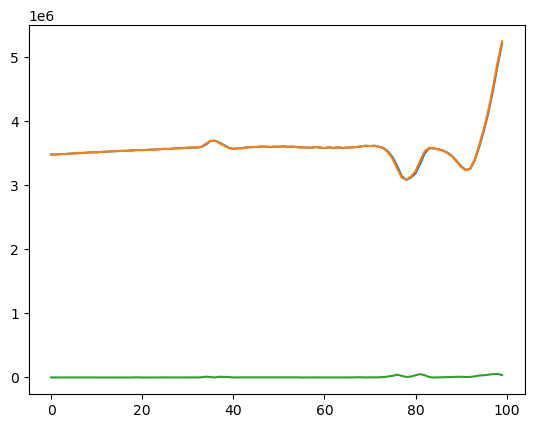

In [3]:
plt.plot(frame_profile[4001])
plt.plot(frame_profile[4000])
plt.plot(np.abs(frame_profile[4001]-frame_profile[4000]))
print(np.argmax(frame_profile[4001]-frame_profile[4000]))

77


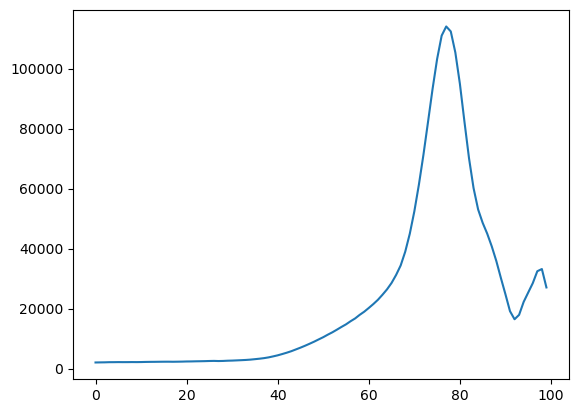

In [4]:
frame_diffs = frame_profile[1:]-frame_profile[:-1]
plt.plot(np.mean(np.abs(frame_diffs), axis=0))
lom = np.argmax(np.mean(np.abs(frame_diffs), axis=0))
print(lom)

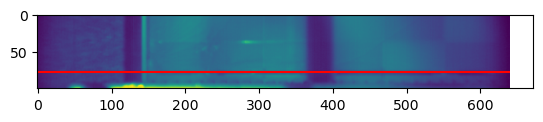

In [5]:
# print(np.min(scan), np.max(scan), scan.shape, scan.dtype)
plt.imshow(scan[4008])
plt.hlines(lom, 0, 640, "r")

In [6]:
scan_profile = frame_profile[:,lom+10]

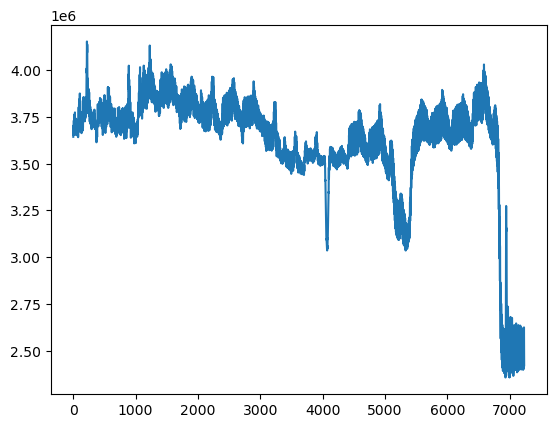

In [7]:
plt.plot(scan_profile)

In [79]:
# peaks, properties = scipy.signal.find_peaks(scan_profile, prominence=0, wlen=1000)
# sorted_index = np.argsort(properties["prominences"])
# peak_1 = peaks[sorted_index[-1]]
# peak_2 = peaks[sorted_index[-2]]
# print(peak_1, peak_2)
# module_start = min(peak_1, peak_2)
# module_end = max(peak_1, peak_2)
# plt.imshow(scan[module_start])
# plt.show()
# plt.imshow(scan[module_end])
# plt.show()

In [80]:
# #scipy envelope??
# #low pass filter or something to detect the large peaks then remove start and end of module for further analysis of the scan
#
# coffs = scipy.signal.butter(2, 1/60, output="sos", btype="lowpass")
# print(coffs)
# low_pass = scipy.signal.sosfilt(coffs, scan_profile)
# plt.plot(low_pass)
#
# peaks, properties = scipy.signal.find_peaks(low_pass, width=0, height=0)
# #plt.plot(peaks, scan_profile[peaks], ".")
# #print(properties["peak_heights"])
# sorted_index = np.argsort(properties["peak_heights"])
# module_start = min(peaks[sorted_index[-1]], peaks[sorted_index[-2]])
# module_end = max(peaks[sorted_index[-2]], peaks[sorted_index[-2]])
# #test_width = int(properties["widths"][sorted_index[-1]])
# print(module_start, module_end)
# plt.vlines((module_start, module_end), 0, np.max(low_pass), "r")
# width_end = properties["widths"][sorted_index[-1]]
# width_start = properties["widths"][sorted_index[-2]]
# print(width_start, width_end)
# plt.vlines((module_start+width_start, module_end-width_end), 0, np.max(low_pass), "g")
#
# plt.imshow(scan[int(module_start+width_start)])
# plt.show()
# plt.imshow(scan[int(module_end-width_start)+2])

In [81]:
# bp_in = (int(50*len(scan_profile)/f_s), None)
# scan_env, scan_res = scipy.signal.envelope(scan_profile, bp_in, n_out = int(len(scan_profile)/7))
# #plt.plot(scan_profile[trim_start:trim_start+12])
# plt.plot(scan_env)
# peaks_test, _ = scipy.signal.find_peaks(scan_env)
# print(peaks_test)
# plt.plot(peaks_test, scan_env[peaks_test], ".r")

In [82]:
# plt.plot(scan_env)
# #plt.plot(scan_res)

In [83]:
# line_profiles = scan[:, 279, :]
# line_env, line_res = scipy.signal.envelope(line_profiles, bp_in, n_out = int(0.3*len(line_profiles)/(int(f_s/f_m))), axis=0)

In [84]:
# plt.plot(line_res[:,0])

In [85]:
# # #Vertical
# # v_profile = line_res.sum(axis=1)
# # plt.plot(v_profile)
# # v_peaks, v_peaks_prop = scipy.signal.find_peaks(v_profile, distance=10, prominence=10000, height=0)
# # #print(res_peaks_prop)
# # plt.plot(v_peaks, v_profile[v_peaks], ".r")
# # plt.show()
# # v_peaks_sort = np.argsort(v_peaks_prop["prominences"])
# # v_mod_start = min(v_peaks[v_peaks_sort[-1]], v_peaks[v_peaks_sort[-2]])
# # v_mod_end = max(v_peaks[v_peaks_sort[-1]], v_peaks[v_peaks_sort[-2]])
# #
# #
# # #Horizontal
# # h_profile = line_res.sum(axis=0)
# # plt.plot(h_profile)
# # h_peaks, h_peaks_prop = scipy.signal.find_peaks(h_profile, distance=10, prominence=70000, height=0)
# # plt.plot(h_peaks, h_profile[h_peaks], ".r")
# # plt.show()
# # h_mod_start = h_peaks[0]
# # h_mod_end = h_peaks[-1]
#
# #Final
# module = line_res[v_mod_start:v_mod_end, h_mod_start:h_mod_end]
# module = line_env
# plt.imshow(module, cmap="gray")
# plt.show()
#
# #module_process = np.uint16(((module-module.min())/(module.max()-module.min()))*2**16)
# module_process = ingaas_processing.lin_stretch_img(module, 0.01, 99.9)
# print(module_process.min(), module_process.max())
# plt.imshow(module_process, cmap="gray")
# plt.show()

In [10]:
test = np.sum(scan, axis=(1,2))
#test = np.sum(frame_diffs, axis=1)

In [87]:
#plt.plot()

In [1]:
test = (150,300)
print(test[0])

150


In [8]:
#Functions
def get_phase(x, f, f_s, debug_out=False):
    '''
    Finds the phase of a given frequency in a signal, sampled at some other frequency.

    Args:
        x: The signal as a numpy array
        f: The frequency to find the phase of
        f_s: The frequency at which the signal was sampled
        debug_out: Whether to display some debug info

    Returns:
        phase: The phase of the signal
        f_out: The closest frequency present in the FFT

    '''

    # Where is the modulation frequency in the results?
    fft_frequencies = scipy.fft.fftshift(scipy.fft.rfftfreq(len(x), d=1/f_s))
    f_index = np.argmin(np.abs(f-fft_frequencies))
    f_out = fft_frequencies[f_index]
    if debug_out:
        print(f_index)
        print(f_out)

    # FFT of data
    yf = scipy.fft.fftshift(scipy.fft.rfft(x))
    if debug_out:
        plt.plot(fft_frequencies, yf)
        plt.show()


    # Get phase
    phase = np.angle(yf[f_index])
    if debug_out:
        print(yf[f_index])
        print("Phase:", phase)

    return phase, f_out

def get_extrema(f,phase,f_s,N):
    '''
    Estimate the extrema points of a discrete signal

    Args:
        f: Frequency of the signal component of interest
        phase: How the signal component is shifted. Should be in the range [-Pi,Pi]
        f_s: Frequency at which the signal is sampled
        start: Index at which to start return from
        end: Index at which to end return at

    Returns:
        peaks: Index of peaks as a numpy array
        valleys: Index of valleys as a numpy array

    '''
    peak_arg =  -phase

    if peak_arg < 0:
        peak_arg += 2*np.pi

    if peak_arg > 2*np.pi:
        peak_arg -= 2*np.pi

    valley_arg = peak_arg + np.pi

    base = np.arange(N)*2*np.pi
    peaks = np.round(f_s*(base+peak_arg)/(2*np.pi*f)).astype(np.int32)
    valleys = np.round(f_s*(base+valley_arg)/(2*np.pi*f)).astype(np.int32)

    #mask = np.all([peaks > start, peaks < end, valleys > start, valleys < end], axis=0)
    mask = np.all([peaks < N, valleys < N], axis=0)
    return peaks[mask], valleys[mask]

In [11]:
#Parameters
f_m = 50 #Hz
#f_s = 300 #Hz
f_s = 299.9 #Hz

start = 2800
wlen = round(f_s)
errors = []
phases = []
window = test[start:start + wlen]
#window = test
phase, f_out = get_phase(window, f_m, f_s)
errors.append((f_out-f_m)**2)
phases.append(phase)

print(phase,f_out)
peaks,valleys = get_extrema(f_m, phase, f_s, len(window))
print(peaks, valleys)

2.029114991817536 49.98333333333333
[  4  10  16  22  28  34  40  46  52  58  64  70  76  82  88  94 100 106
 112 118 124 130 136 142 148 154 160 166 172 178 184 190 196 202 208 214
 220 226 232 238 244 250 256 262 268 274 280 286 292] [  7  13  19  25  31  37  43  49  55  61  67  73  79  85  91  97 103 109
 115 121 127 133 139 145 151 157 163 169 175 181 187 193 199 205 211 217
 223 229 235 241 247 253 259 265 271 277 283 289 295]


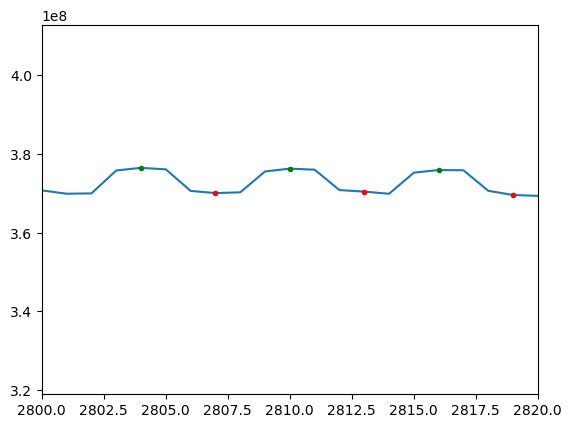

-1.1872661989356903
1.8117338010643094


In [12]:
x_start=start
x_end=start+20

plt.plot(test)
plt.plot(peaks+start, test[peaks+start], ".g")
plt.plot(valleys+start, test[valleys+start], ".r")
plt.xlim(x_start, x_end)
plt.show()
# x = np.arange(len(test))
# y = np.sin(2*np.pi*x*f_m/f_s + phase) + np.cos(2*np.pi*x*f_m/f_s + phase)
# plt.xlim(x_start,x_end)
# plt.plot(x,y)
# plt.plot(peaks+start, y[peaks+start], ".g")
# plt.plot(valleys+start, y[valleys+start], ".r")
# plt.show()

print(f_s*(np.pi/4 - phase)/(2*np.pi*f_m))
print(f_s*(5*np.pi/4 - phase)/(2*np.pi*f_m))

In [13]:
data = scan[2800:]
#signal = np.sum(scan, axis=(1,2))
signal = test[2800:]

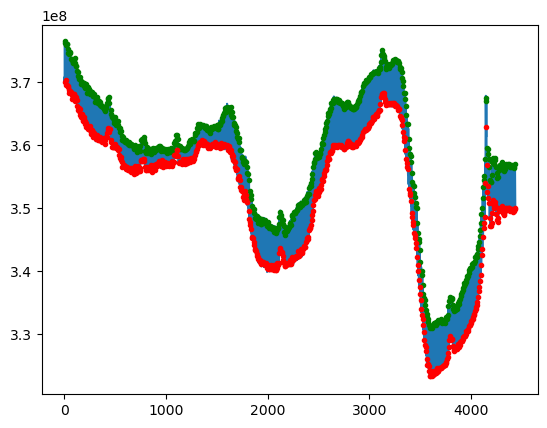

(array([-3, -2], dtype=int32), array([729,   1]))
77


In [14]:
#Parameters
f_m = 50 #Hz
#f_s = 300 #Hz
f_s = 299.917668 #Hz

start = 0
wlen = 600

N = len(signal)

min_steps = np.ceil(N/wlen).astype(np.int32)
steps = 10+min_steps
step_size = (N-start-wlen)/(steps-1)
#print(step_size)

peaks = np.empty(0, dtype=np.int32)
valleys = np.empty(0, dtype=np.int32)
for i in range(steps):
    w_start = round(i*step_size)+start
    w_end = w_start+wlen
    w_start_next = round((i+1)*step_size)+start
    #print(w_start, w_end, w_start_next)
    if w_end+10 > N:
        w_start_next = w_end

    window = signal[w_start:w_end]
    phase, f_out = get_phase(window, f_m, f_s)
    peaks_i,valleys_i = get_extrema(f_m, phase, f_s, w_start_next-w_start)
    #print(peaks_i,valleys_i)
    peaks = np.append(peaks, peaks_i+w_start)
    valleys = np.append(valleys, valleys_i+w_start)

plt.plot(signal)
plt.plot(peaks, signal[peaks], ".g")
plt.plot(valleys, signal[valleys], ".r")
plt.show()

print(np.unique(peaks-valleys, return_counts=True))
frame_profile = np.sum(scan, axis=2)
frame_diffs = frame_profile[1:]-frame_profile[:-1]
#plt.plot(np.mean(np.abs(frame_diffs), axis=0))
lom = np.argmax(np.mean(np.abs(frame_diffs), axis=0))
print(lom)
result = data[peaks,:,:] - data[valleys,:,:]
stitch = result[:,lom,:]

In [15]:
print(np.max(scan), np.min(scan))
print(np.max(stitch), np.min(stitch))

15579 1746
1798 -431


In [16]:
print(result.argmax(axis=1))
plt.imshow(result[900], cmap="gray")
plt.show()
stitch_process = ingaas_processing.lin_stretch_img(stitch, low_prc=0.3,high_prc=99.7)
plt.imshow(stitch_process, cmap="gray", vmin=np.min(stitch_process), vmax=np.max(stitch_process))
#im = Image.fromarray(ingaas_processing.lin_stretch_img(stitch[::2,:], low_prc=0.05,high_prc=99.95))
#im.save(scan_path[:-4]+"_processed.png")
#im.save()

[[58 58 58 ...  1 26 87]
 [89 89 86 ... 90 99 70]
 [71 75 59 ... 13  9 90]
 ...
 [43 43 43 ... 99 25 51]
 [74 23  0 ... 26 59 39]
 [42 10 15 ... 14 28 99]]


IndexError: index 900 is out of bounds for axis 0 with size 730

In [17]:
stitch_resize = cv2.resize(stitch_process, (stitch_process.shape[1], int(stitch_process.shape[0]/2.5)))
plt.imshow(stitch_resize, cmap="gray", vmin=np.min(stitch_resize), vmax=np.max(stitch_resize))

NameError: name 'stitch_process' is not defined

uint8


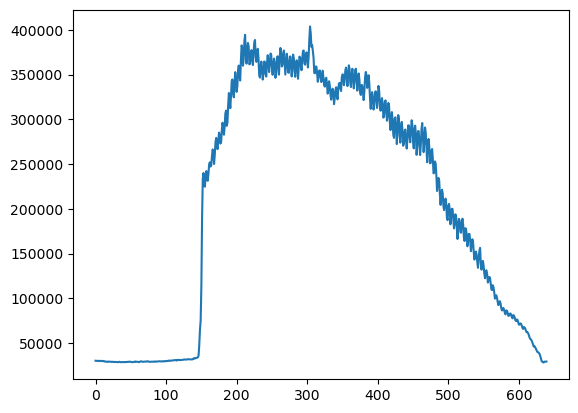

In [17]:
plt.plot(stitch_process.sum(axis=0))
print(stitch_process.dtype)

In [18]:
dist=2
prom = 0
peaks=scipy.signal.find_peaks(signal, distance=dist,prominence=prom)[0]
valleys=scipy.signal.find_peaks(-signal, distance=dist, prominence=prom)[0]
points = min(len(peaks), len(valleys))
peaks = peaks
valleys = valleys
np.unique(peaks-valleys, return_counts=True)

(array([-4, -3, -2, -1]), array([ 309, 1613,   50,    1]))

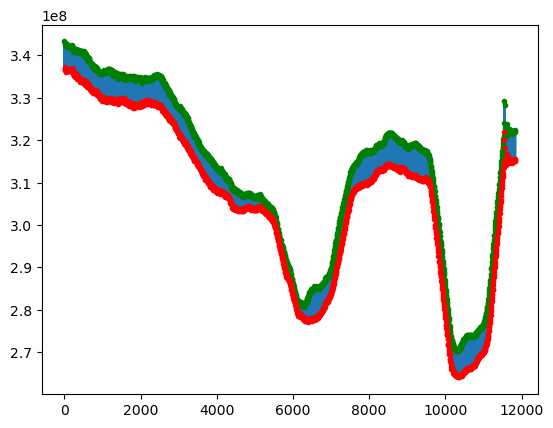

In [19]:
plt.plot(signal)
plt.plot(peaks, signal[peaks], ".g")
plt.plot(valleys, signal[valleys], ".r")

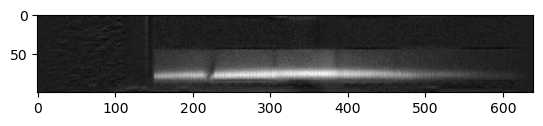

In [20]:
#print(scan.shape)
test_out = data[peaks] - data[valleys]
plt.imshow(test_out[400], cmap="gray")

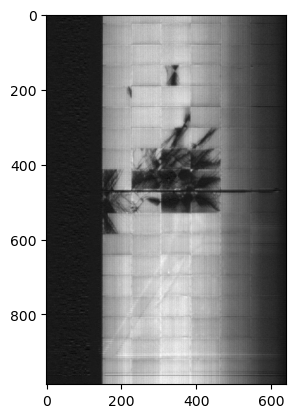

In [21]:
plt.imshow(ingaas_processing.lin_stretch_img(test_out[::2,lom,:], 0.05, 99.95), cmap="gray")

TypeError: Invalid shape (658, 100, 640) for image data

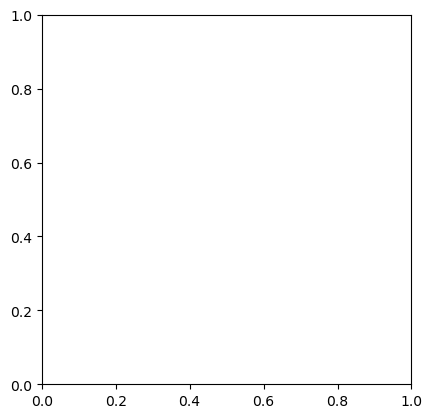

In [22]:
test_out_down = scipy.signal.decimate(test_out, 3, axis=0)
plt.imshow(ingaas_processing.lin_stretch_img(test_out_down, 0.1, 99.9), cmap="gray")

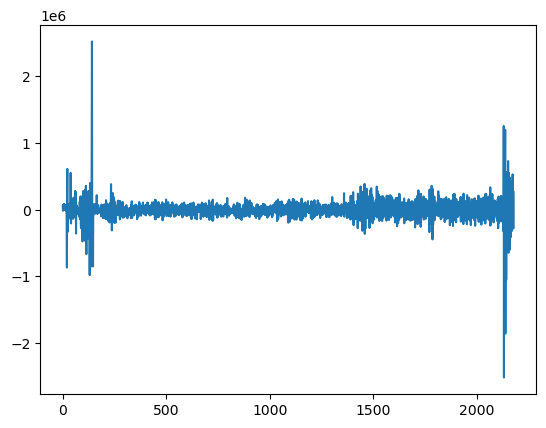

In [40]:
test_sum = np.sum(test_out,axis=1)
plt.plot(test_sum)
# peaks_out = scipy.signal.find_peaks(test_sum, distance=10)[0]
# plt.plot(peaks_out, test_sum[peaks_out], ".g")
# peaks_sorted = peaks_out[np.argsort(test_sum[peaks_out])]
# peak_1, peak_2 = peaks_sorted[0], peaks_sorted[-1]
# mod_start
# plt.plot(peaks_top_2, test_sum[peaks_top_2], ".r")

In [41]:
np.any(peaks==valleys)

False

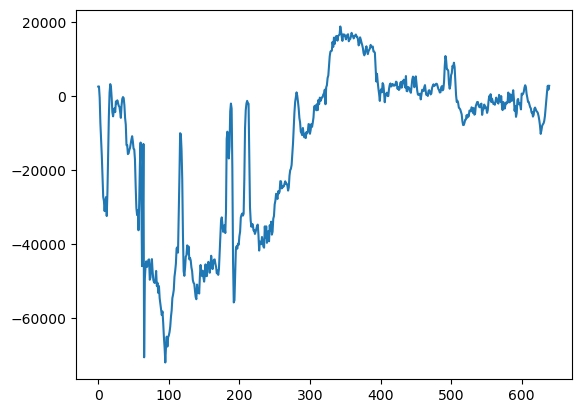

In [42]:
plt.plot(np.sum(test_out,axis=0))

In [43]:
filter_iir = scipy.signal.iirpeak(w0=50, Q=1, fs=f_s)
filtered_test = scipy.signal.filtfilt(filter_iir[0], filter_iir[1], scan[:, lom, :], axis=0)

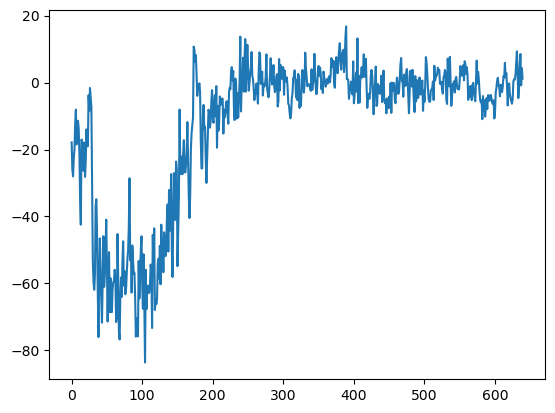

In [44]:
plt.plot(filtered_test[300])